## Introduction

This notebook shows training of the ResNet model - First CNN appraoch.

## Setup

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from skin_lesion_project.processing.image_processing import training_data_transforms, test_val_transforms

from skin_lesion_project.datasets.dataloader import create_dataloaders
from skin_lesion_project.models.resnet import get_resnet50
from skin_lesion_project.training.train import train

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")

NUM_CLASSES = 8
BATCH_SIZE = 8
EPOCHS = 30
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

Device : cuda
GPU : NVIDIA GeForce MX150


In [3]:
DEVICE

device(type='cuda')

## Data Loaders

In [6]:
train_loader, val_loader, class_weights = create_dataloaders(
    train_transform=training_data_transforms(),
    val_transform=test_val_transforms(),
    bucket_name="skin-lesion-data-bucket",
    train_image_prefix="train",
    train_label_key="labels/mappings.pkl",
    val_image_prefix="test",
    val_label_key="labels/mappings_test.pkl",
    batch_size=8,
)

Training Images   : 30931
Validation Images : 8238
Batch Size        : 8
Workers           : 4


## Images

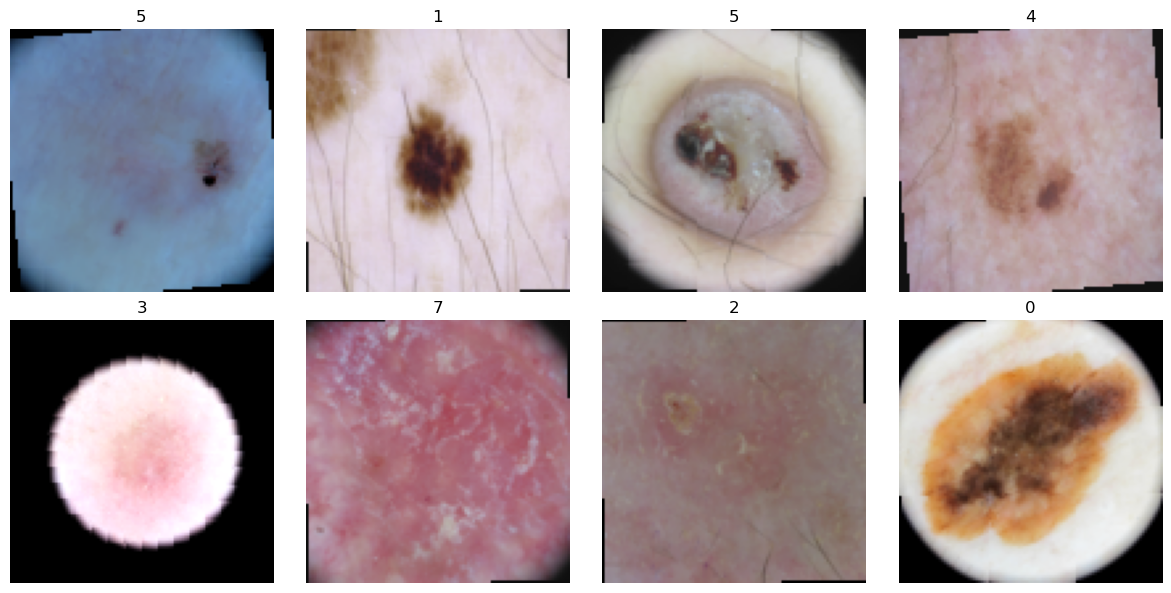

In [7]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2,4, figsize=(12,6))
mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

for i, ax in enumerate(axes.flat):
    image = images[i].cpu()
    image = image * std + mean
    image = image.clamp(0,1)
    ax.imshow(image.permute(1,2,0))
    ax.set_title(labels[i].item())
    ax.axis("off")
plt.tight_layout()
plt.show()

## ResNet Model

In [8]:
model = get_resnet50(num_classes=NUM_CLASSES, pretrained=True)
model.to(DEVICE)
model.freeze_backbone()

In [9]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE), label_smoothing=0.1)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = train(model=model, train_loader=train_loader, val_loader=val_loader,
                criterion=criterion, optimizer=optimizer,
                scheduler=scheduler, device=DEVICE,
                epochs=EPOCHS, checkpoint_path="checkpoints/resnet50_classifier.pt")

Epoch 1/30:   2%|███▏                                                                                                                                           | 85/3867 [00:45<33:35,  1.88it/s, loss=1.5075]


KeyboardInterrupt: 